# 📊 Notebook 1 — Exploratory Data Analysis

**Dataset:**
- **UCI-2015**: UCI Phishing Websites (Kaggle/UCI 2015) — used by Saeed (2025) as baseline

**Reference baseline paper:**
> Saeed, E.M.H. (2025). *An Ensemble Voting Classifier based on Machine Learning Models for Phishing Detection.* IJSRSET, 12(1), 15–27. DOI: 10.32628/IJSRSET251211

This notebook covers:
1. Dataset loading and structure overview
2. Class distribution analysis
3. Missing value and data type audit
4. Duplicate row analysis (data integrity)
5. Feature distribution plots
6. Correlation heatmap
7. Feature-class relationship analysis
8. Summary


In [1]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120
})

FIGDIR = '.'   # change to your output folder if needed
SEED   = 42
print('✅ Setup complete.')

✅ Setup complete.


In [2]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

# --- UCI-2015: UCI Phishing Websites (used by Saeed 2025) ---
# Labels: 1 = phishing, -1 = legitimate
df_base_raw = pd.read_csv('UCI-2015.csv')
df_base_raw = df_base_raw.drop(columns=['Index'], errors='ignore')
# Standardise label: phishing=1, legitimate=0
df_base_raw['label'] = df_base_raw['class'].map({1: 1, -1: 0})
df_base_raw = df_base_raw.drop(columns=['class'])

print('UCI-2015 shape:', df_base_raw.shape)
print()
print('Columns:', df_base_raw.drop(columns=['label']).columns.tolist())


UCI-2015 shape: (11054, 31)

Columns: ['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']


In [3]:
# ==========================================
# 3. DATASET OVERVIEW
# ==========================================

df = df_base_raw
name = 'UCI-2015'

print(f'{"="*55}')
print(f'  {name}')
print(f'{"="*55}')
print(f'  Rows:         {len(df):,}')
print(f'  Features:     {len(df.columns)-1}')
print(f'  Missing vals: {df.isnull().sum().sum()}')
print(f'  Duplicates:   {df.duplicated().sum():,}  ({df.duplicated().sum()/len(df)*100:.1f}%)')
print(f'  Unique rows:  {len(df.drop_duplicates()):,}')
vc = df['label'].value_counts()
print(f'  Phishing:     {vc.get(1,0):,}  ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  Legitimate:   {vc.get(0,0):,}  ({vc.get(0,0)/len(df)*100:.1f}%)')
ratio = min(vc)/max(vc)
print(f'  Imbalance ratio: {ratio:.3f}  ({"balanced" if ratio > 0.8 else "imbalanced"})')


  UCI-2015
  Rows:         11,054
  Features:     30
  Missing vals: 0
  Duplicates:   5,205  (47.1%)
  Unique rows:  5,849
  Phishing:     6,157  (55.7%)
  Legitimate:   4,897  (44.3%)
  Imbalance ratio: 0.795  (imbalanced)


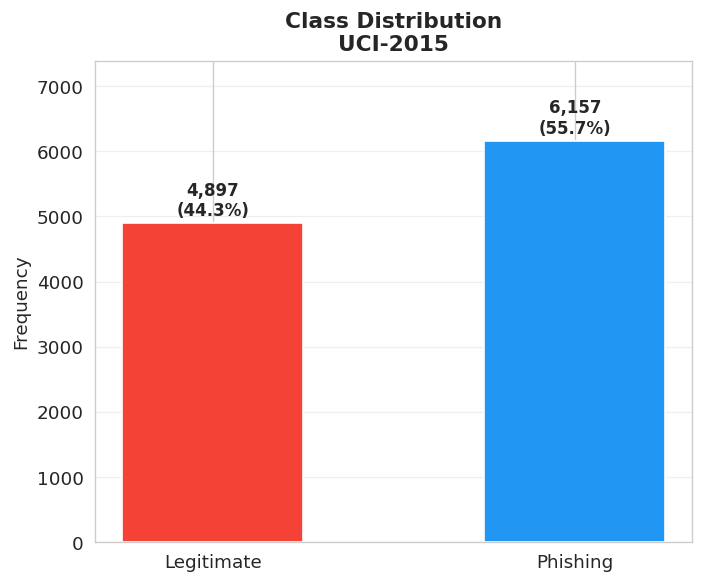

Saved: eda_class_distribution.png


In [4]:
# ==========================================
# 4. CLASS DISTRIBUTION — FIGURE
# ==========================================

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#2196F3', '#F44336']  # blue=legitimate, red=phishing

vc = df_base_raw['label'].value_counts().sort_index()
labels_map = {0: 'Legitimate', 1: 'Phishing'}
bars = ax.bar([labels_map[i] for i in vc.index], vc.values, color=colors[::-1], edgecolor='white', width=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{v:,}\n({v/len(df_base_raw)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution\nUCI-2015', fontweight='bold')
ax.set_ylabel('Frequency')
ax.set_ylim(0, max(vc.values) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_class_distribution.png')


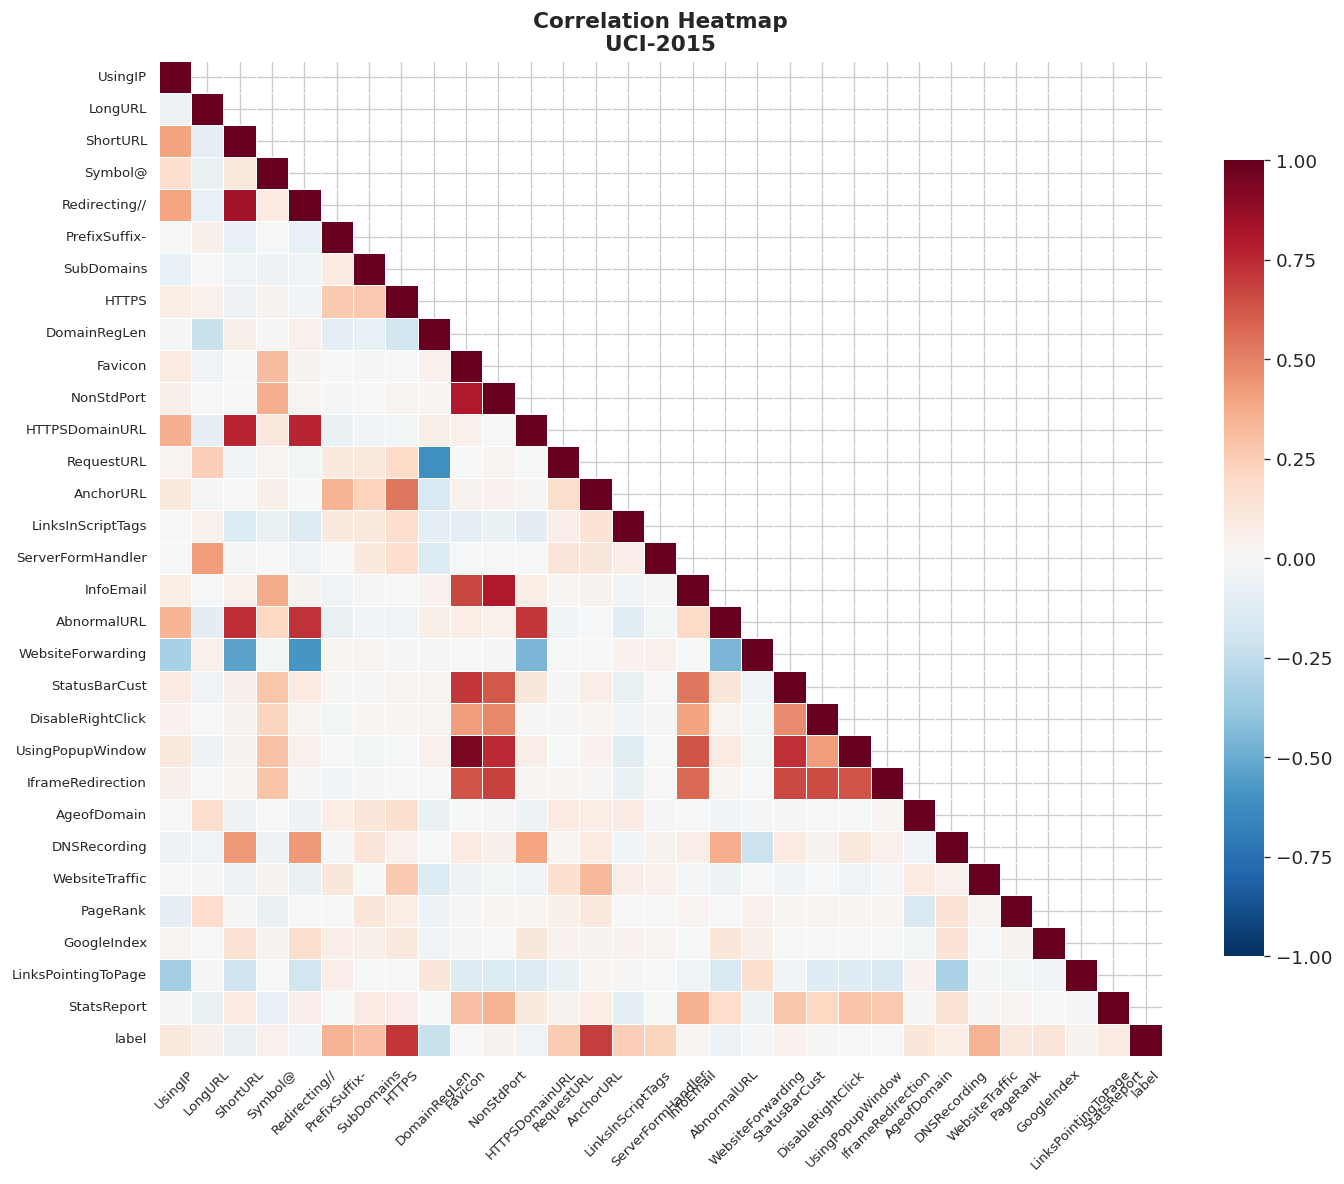

Saved: eda_correlation_heatmap.png


In [5]:
# ==========================================
# 5. CORRELATION HEATMAP
# ==========================================

fig, ax = plt.subplots(figsize=(12, 10))

corr = df_base_raw.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(
    corr, ax=ax, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=(len(df_base_raw.columns) <= 18),
    fmt='.1f', annot_kws={'size': 7},
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap\nUCI-2015', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation_heatmap.png')


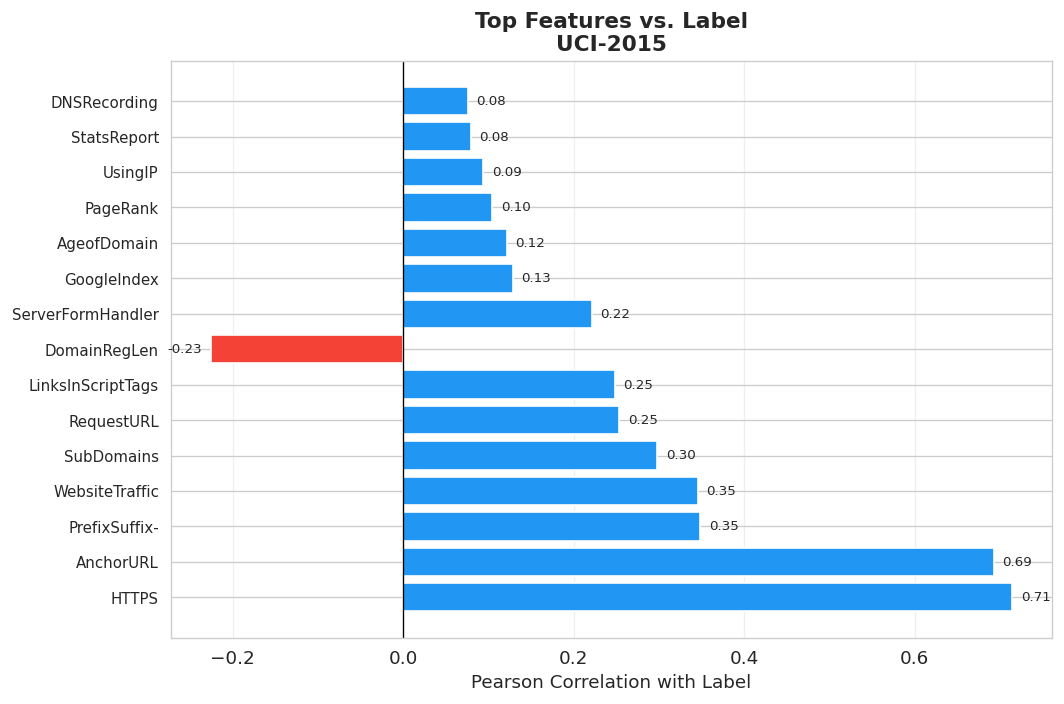

Saved: eda_feature_label_correlation.png


In [6]:
# ==========================================
# 6. TOP FEATURES CORRELATED WITH LABEL
# ==========================================

fig, ax = plt.subplots(figsize=(9, 6))

corr_label = df_base_raw.corr()['label'].drop('label').sort_values(key=abs, ascending=False)
top_n = min(15, len(corr_label))
top = corr_label.head(top_n)
colors_bar = ['#F44336' if v < 0 else '#2196F3' for v in top.values]
bars = ax.barh(range(len(top)), top.values, color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Label')
ax.set_title('Top Features vs. Label\nUCI-2015', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, top.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_feature_label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_feature_label_correlation.png')


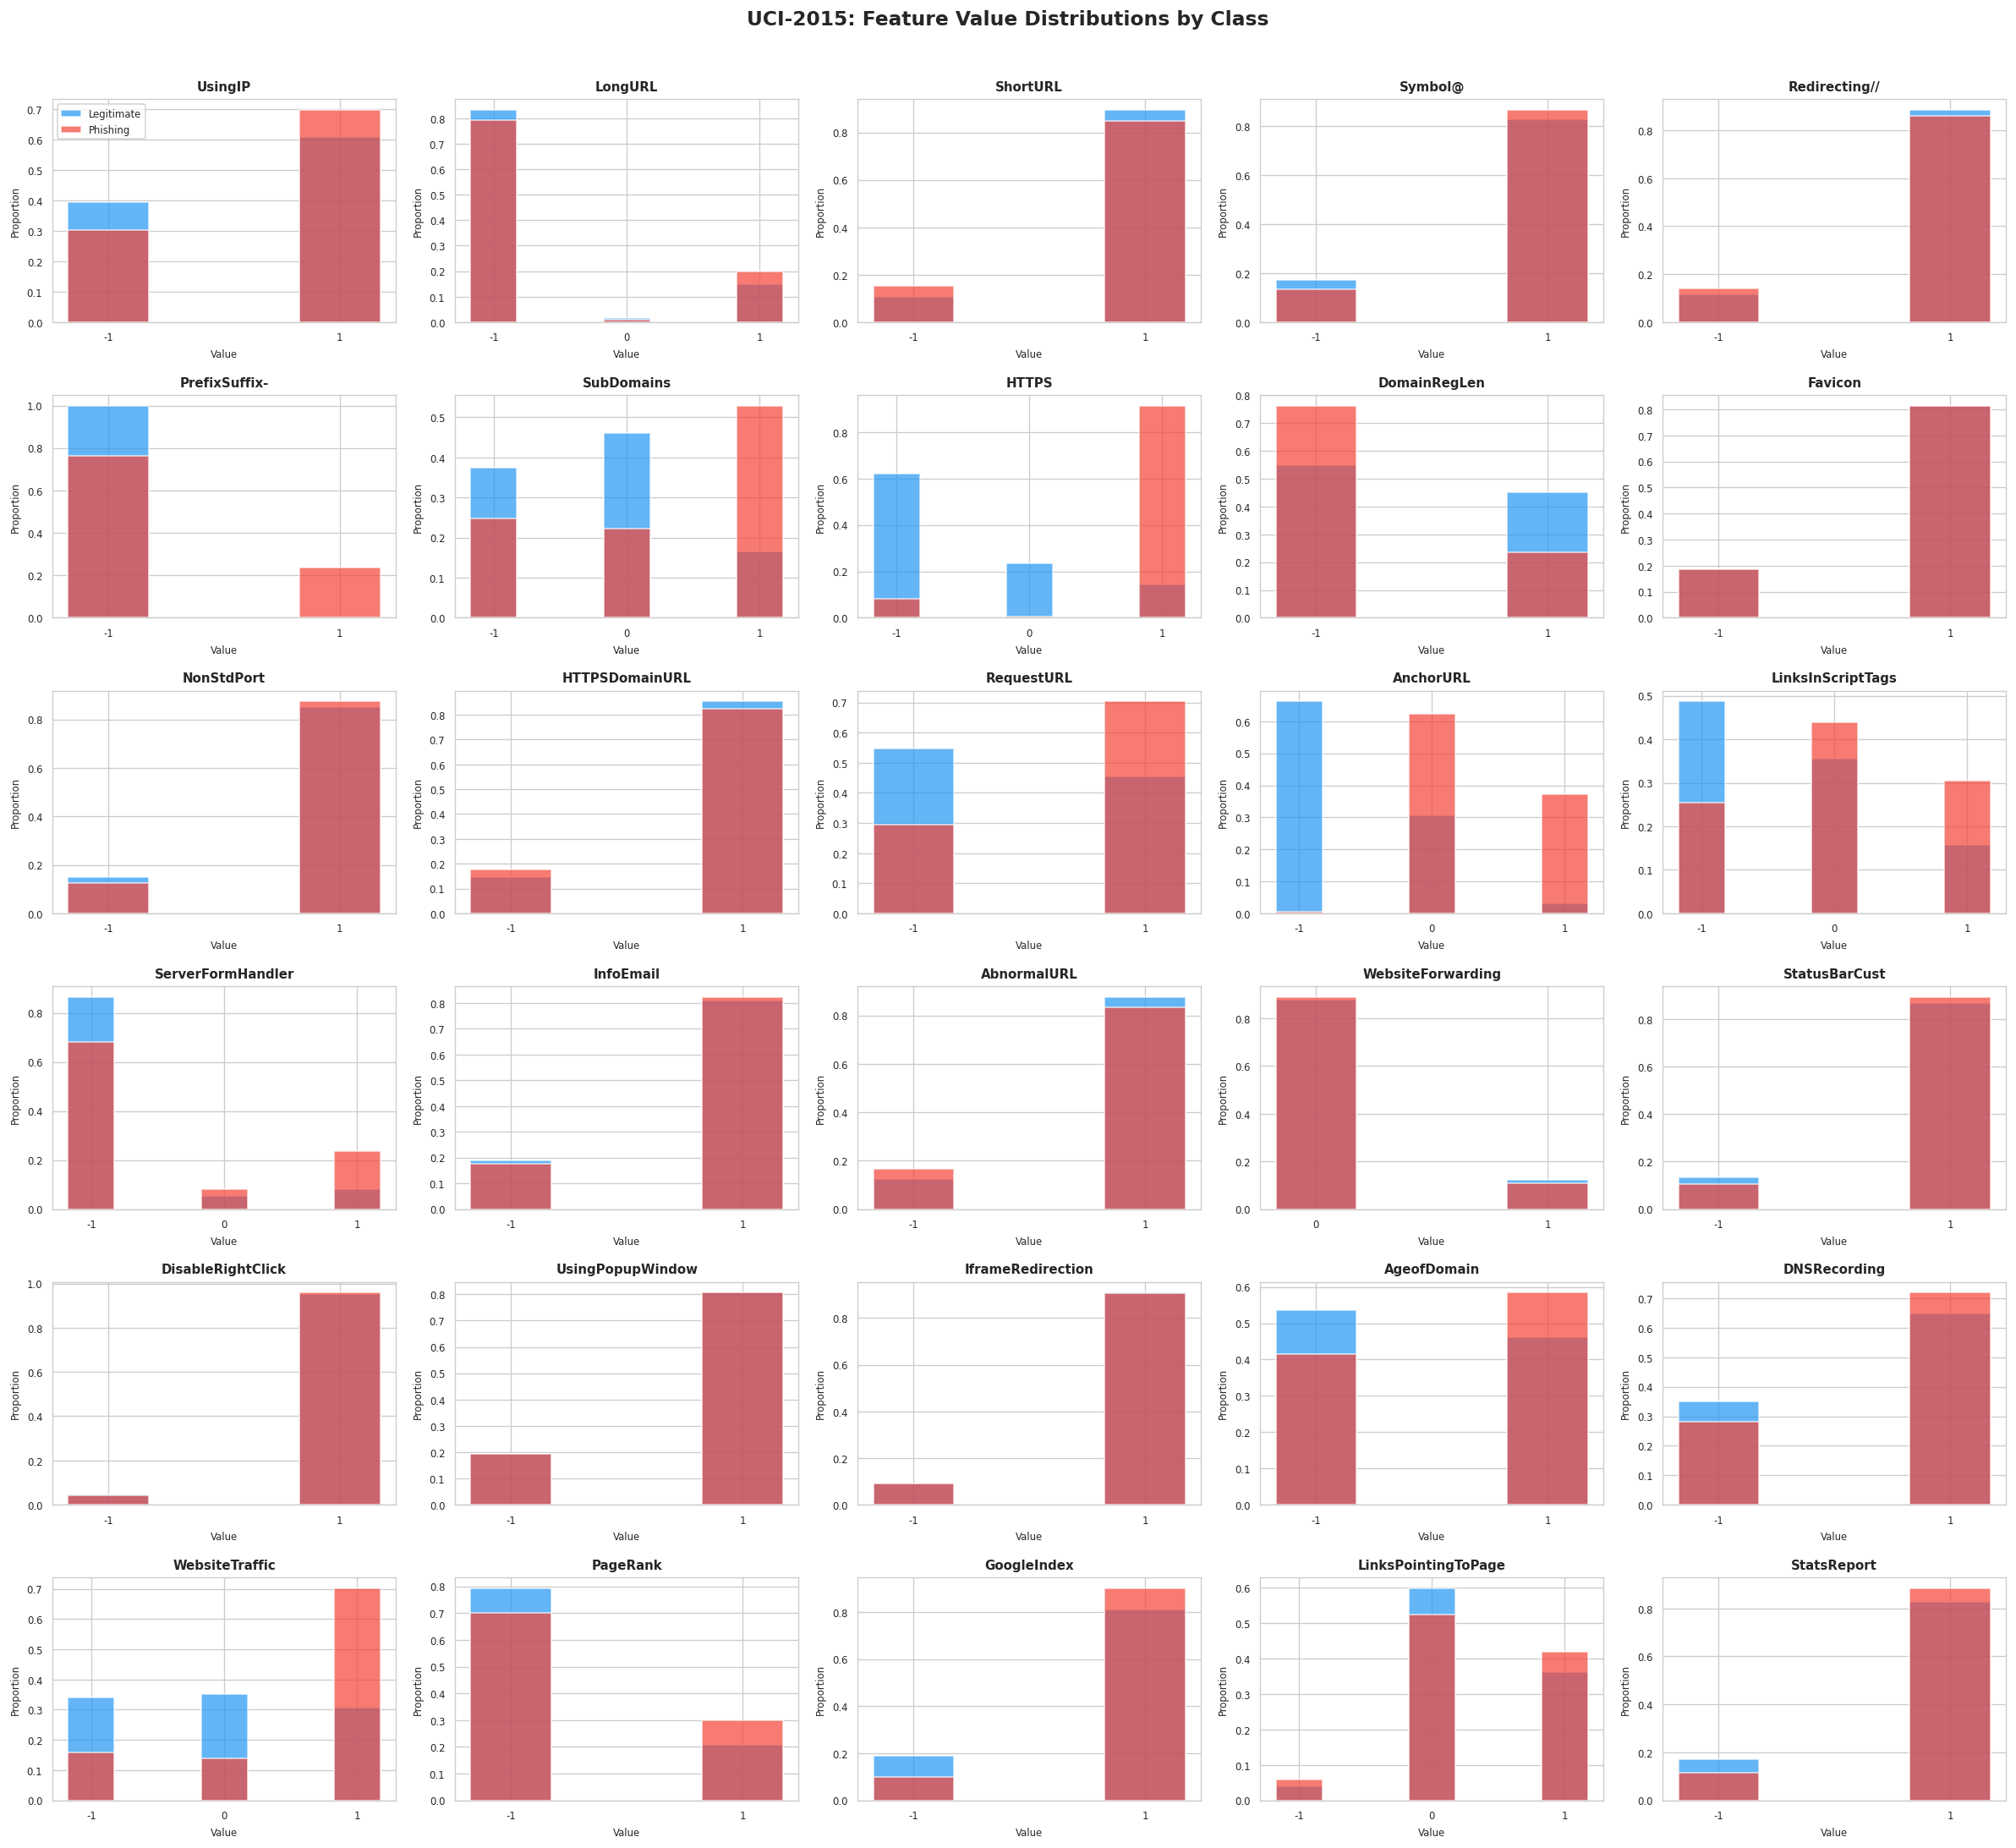

Saved: eda_feature_distributions.png


In [7]:
# ==========================================
# 7. FEATURE DISTRIBUTIONS — UCI-2015
# ==========================================
# UCI-2015 has categorical {-1, 0, 1} features — bar plots per class

feats_base = df_base_raw.drop(columns=['label']).columns.tolist()
n_cols = 5
n_rows = int(np.ceil(len(feats_base) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(feats_base):
    ax = axes[i]
    for cls, color, label in [(0, '#2196F3', 'Legitimate'), (1, '#F44336', 'Phishing')]:
        sub = df_base_raw[df_base_raw['label'] == cls][feat].value_counts(normalize=True).sort_index()
        ax.bar([str(v) for v in sub.index], sub.values,
               alpha=0.7, color=color, label=label, width=0.35,
               align='center')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Proportion', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0: ax.legend(fontsize=7)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('UCI-2015: Feature Value Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: eda_feature_distributions.png')


In [8]:
# ==========================================
# 8. NEAR-CONSTANT / LOW VARIANCE FEATURES
# ==========================================

print('--- UCI-2015 ---')
feats = df_base_raw.drop(columns=['label'])
const = [c for c in feats.columns if feats[c].nunique() <= 1]
near  = [c for c in feats.columns if feats[c].value_counts(normalize=True).max() > 0.99 and c not in const]
print(f'  Zero-variance features:      {const if const else "None ✅"}')
print(f'  Near-constant (>99% 1 val):  {near if near else "None ✅"}')


--- UCI-2015 ---
  Zero-variance features:      None ✅
  Near-constant (>99% 1 val):  None ✅


In [9]:
# ==========================================
# 9. SUMMARY TABLE
# ==========================================

vc = df_base_raw['label'].value_counts()
dups = df_base_raw.duplicated().sum()

summary = pd.DataFrame([
    {
        'Dataset':        'UCI-2015',
        'Paper':          'Saeed (2025)',
        'Rows':           f'{len(df_base_raw):,}',
        'Features':       str(len(df_base_raw.columns) - 1),
        'Feature Type':   'Categorical {-1, 0, 1}',
        'Phishing %':     f"{df_base_raw['label'].mean()*100:.1f}%",
        'Legitimate %':   f"{(1 - df_base_raw['label'].mean())*100:.1f}%",
        'Duplicate Rows': f"{dups:,} ({dups/len(df_base_raw)*100:.1f}%)",
        'Missing Values': str(df_base_raw.isnull().sum().sum()),
        'Imbalance Ratio':f"{min(vc)/max(vc):.3f}",
    }
])

print('\n📌 EDA SUMMARY — UCI-2015')
print(summary.T.to_string())



📌 EDA SUMMARY — UCI-2015
                                      0
Dataset                        UCI-2015
Paper                      Saeed (2025)
Rows                             11,054
Features                             30
Feature Type     Categorical {-1, 0, 1}
Phishing %                        55.7%
Legitimate %                      44.3%
Duplicate Rows            5,205 (47.1%)
Missing Values                        0
Imbalance Ratio                   0.795
